<a href="https://colab.research.google.com/github/chetankumar-rs/ML-Projects/blob/main/mini_data_preprocessed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np

In [64]:
import pandas as pd

In [65]:
import matplotlib.pyplot as plt

In [66]:
import sklearn

In [67]:
import seaborn as sns

In [68]:
import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv('/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [70]:
df.shape

(225745, 79)

In [71]:
df.head(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,54871,1022,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,54925,4,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,54925,42,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,9282,4,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,55153,4,2,0,37,0,31,6,18.5,17.67767,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [72]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
139411,54577,1994072,1,6,6,36,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
43429,80,3170514,4,0,24,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
46334,80,4052895,4,0,24,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
107651,80,890607,3,6,26,11601,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
152650,80,1110410,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
53457,80,1405191,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
41551,52011,5509795,1,6,6,36,6,6,6.000000,0.000000,...,20,29975.0,0.0,29975,29975,5479820.0,0.0,5479820,5479820,BENIGN
109424,80,4928935,5,0,30,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
194233,49427,907498,8,2,11607,26,4380,0,1450.875000,1733.674499,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
153449,80,643837,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS


In [73]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [74]:
df.columns = df.columns.str.strip()

In [75]:
df.loc[:,'Label'].unique()

array(['BENIGN', 'DDoS'], dtype=object)

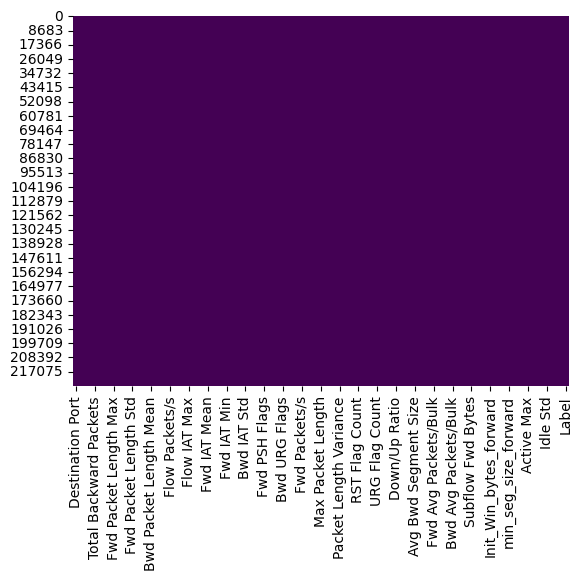

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

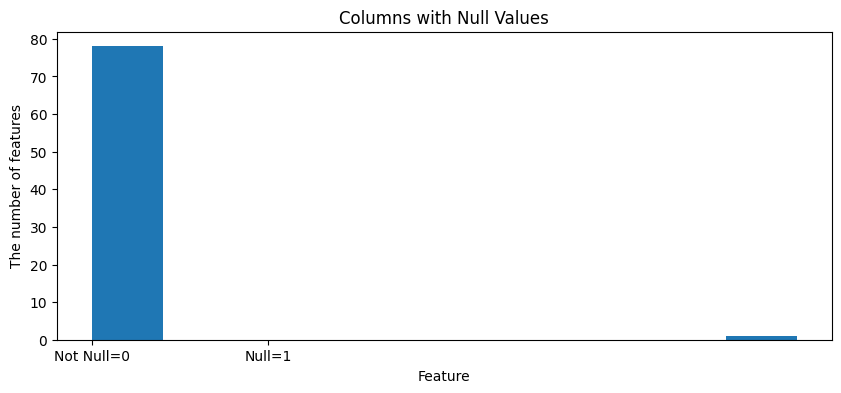

In [77]:
plt.figure(1,figsize=( 10,4))
plt.hist( df.isna().sum())
# Set the title and axis labels
plt.xticks([0, 1], labels=['Not Null=0', 'Null=1'])
plt.title('Columns with Null Values')
plt.xlabel('Feature')
plt.ylabel('The number of features')

# Show the plot
plt.show()

In [78]:
df.isna().sum()


,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [79]:
(df.isna().sum() > 0).sum()

np.int64(1)

In [80]:
(df.isna().sum() == 0).sum()

np.int64(78)

In [81]:
df.isna().sum().sum()

np.int64(4)

In [82]:
df.isna().sum()[df.isna().sum() > 0]

,0
Flow Bytes/s,4


In [83]:
total_columns = df.shape[1]
columns_with_nulls = (df.isna().sum() > 0).sum()
columns_without_nulls = (df.isna().sum() == 0).sum()
total_missing_values = df.isna().sum().sum()

print(f"Total columns: {total_columns}")
print(f"Columns with nulls: {columns_with_nulls}")
print(f"Columns without nulls: {columns_without_nulls}")
print(f"Total missing values: {total_missing_values}")


Total columns: 79
Columns with nulls: 1
Columns without nulls: 78
Total missing values: 4


In [88]:
print("\nColumns with missing values:")
print(df.isna().sum()[df.isna().sum() > 0])



Columns with missing values:
Flow Bytes/s      34
Flow Packets/s    34
dtype: int64


In [89]:
df2 = df.dropna()

In [90]:
df2.isna().any().any()

np.False_

In [100]:
df2 = df2.replace([np.inf, -np.inf], np.nan)
null_values = df2.isnull().sum()

In [102]:
df2.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
48783,80,74213663,8,6,56,11601,20,0,7.000000,5.656854,...,20,2010.0,0.0,2010,2010,36900000.0,36000000.0,62400000,11400000,DDoS
75728,80,78568306,9,4,62,11607,20,0,6.888889,5.301991,...,20,3498.0,0.0,3498,3498,39200000.0,46700000.0,72200000,6235339,DDoS
221144,443,3363760,5,6,279,188,216,0,55.800000,91.870561,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
61428,20397,1417500,1,6,6,36,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
155475,53,185,2,2,60,264,30,30,30.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
166364,37787,9363525,1,5,6,30,6,6,6.000000,0.000000,...,20,20815.0,0.0,20815,20815,9342710.0,0.0,9342710,9342710,BENIGN
204403,80,4,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
14721,53,214,2,2,112,368,56,56,56.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
88576,80,91355,3,6,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
169291,80,101230136,8,5,56,11607,20,0,7.000000,5.656854,...,20,1762398.0,0.0,1762398,1762398,98100000.0,0.0,98100000,98100000,DDoS


In [106]:
(df2.dtypes=='object')

np.int64(79)

In [105]:
object_cols = df2.columns[df2.dtypes == 'object']
print("Columns with object dtype:")
print(object_cols)

Columns with object dtype:
Index(['Label'], dtype='object')


In [107]:
df2['Label'] = df2['Label'].map({'BENIGN': 0, 'DDoS': 1})

In [108]:
df2.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


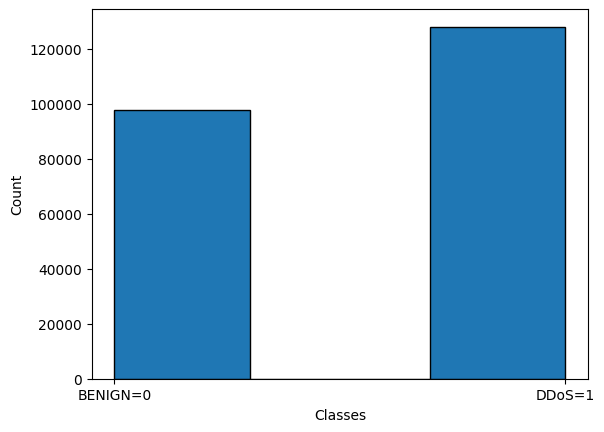

In [109]:
plt.hist(df2['Label'], bins=[0, 0.3,0.7,1], edgecolor='black')  # Specify bins as [0, 1]
plt.xticks([0, 1], labels=['BENIGN=0', 'DDoS=1'])
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

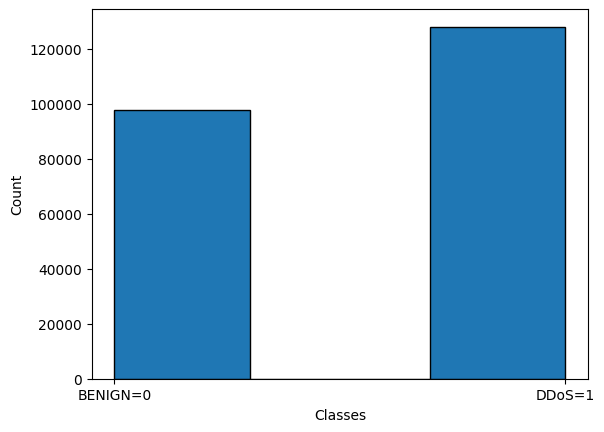

In [111]:
plt.hist(df2['Label'], bins=[0, 0.3, 0.7, 1], edgecolor='black')
plt.xticks([0, 1], labels=['BENIGN=0', 'DDoS=1'])
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()


In [112]:
df2.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,225711.000000,2.257110e+05,225711.000000,225711.000000,225711.000000,2.257110e+05,225711.000000,225711.000000,225711.000000,225711.000000,...,225711.000000,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,225711.000000
mean,8876.556769,1.624410e+07,4.875389,4.573424,939.603147,5.961369e+03,538.615499,27.885810,164.850580,214.939117,...,21.482338,1.848539e+05,1.293631e+04,2.081162e+05,1.776468e+05,1.032370e+07,3.612487e+06,1.288007e+07,7.756523e+06,0.567208
std,19752.018851,3.152612e+07,15.423986,21.756929,3249.628245,3.922122e+04,1864.258043,163.336194,504.927243,797.466898,...,4.166228,7.979819e+05,2.102894e+05,9.002992e+05,7.843163e+05,2.185431e+07,1.275778e+07,2.692283e+07,1.983236e+07,0.495464
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,80.000000,7.123800e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,80.000000,1.453164e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,80.000000,8.806652e+06,5.000000,5.000000,64.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,20.000000,1.879000e+03,0.000000e+00,1.879000e+03,1.863000e+03,8.241416e+06,0.000000e+00,8.254452e+06,7.423865e+06,1.000000
max,65532.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08,1.000000


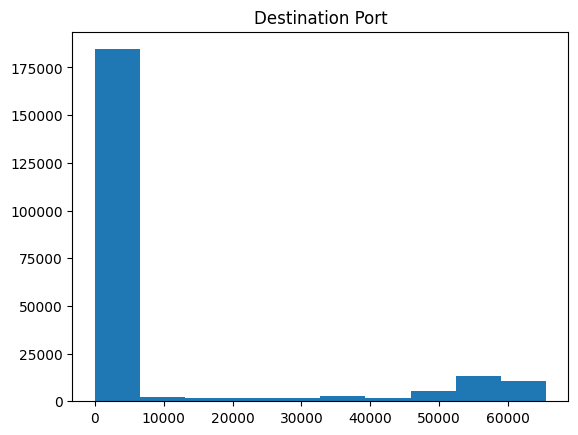

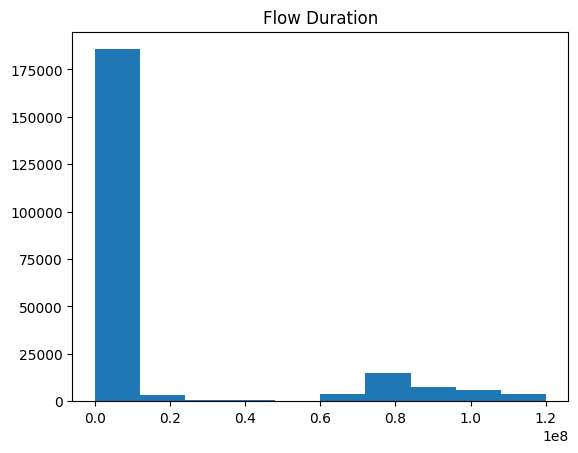

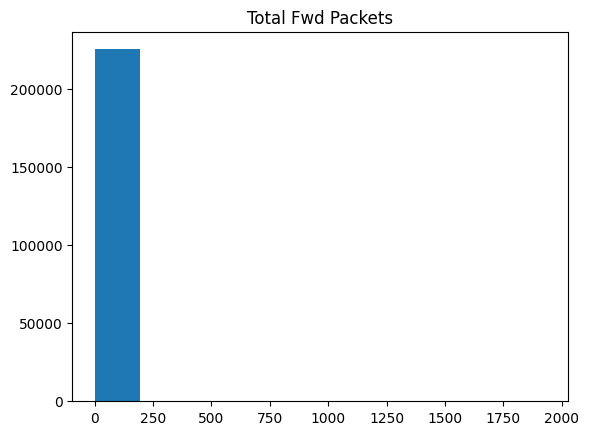

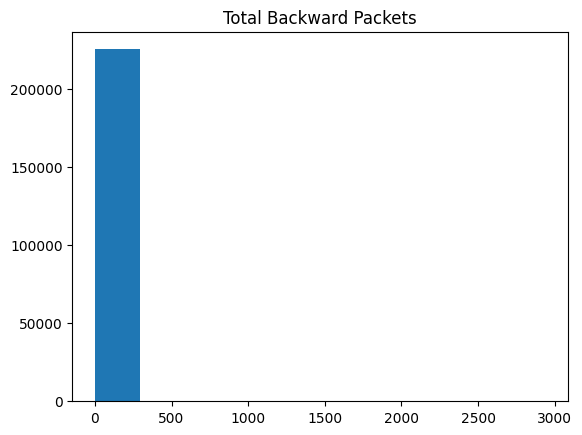

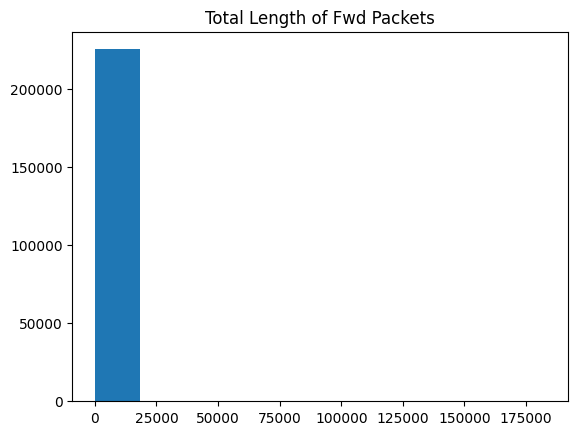

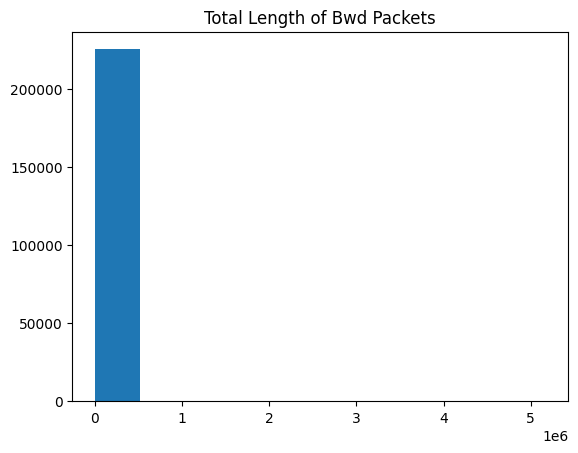

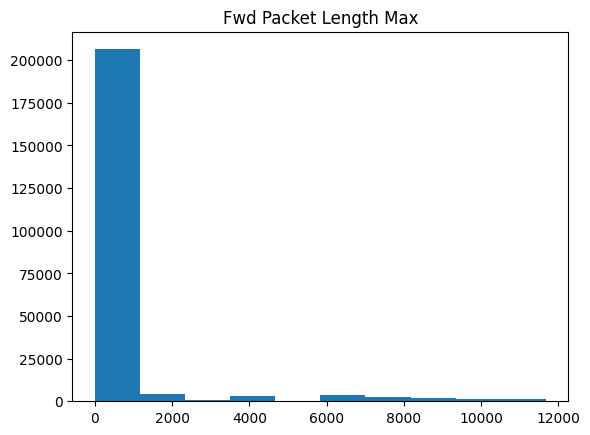

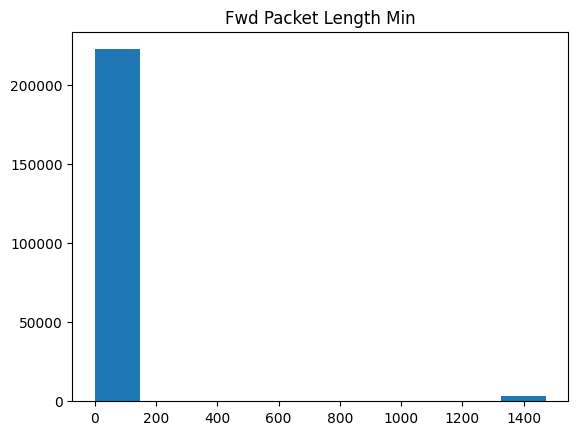

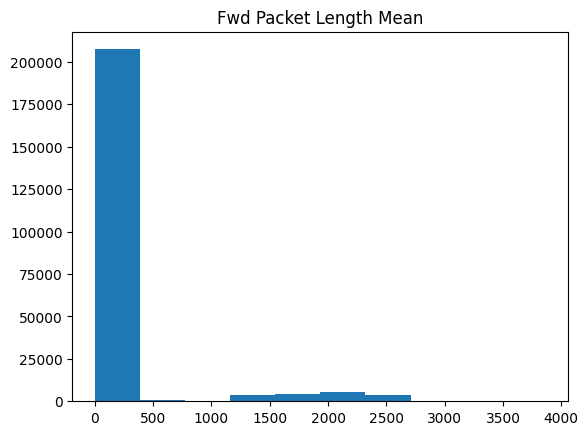

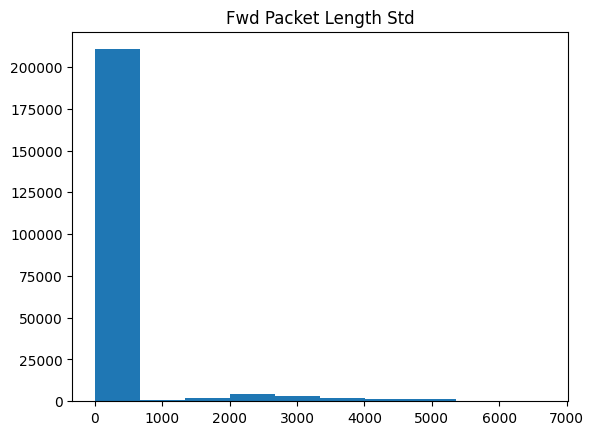

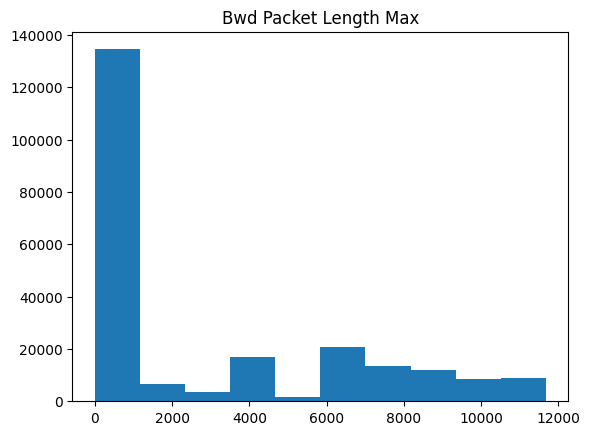

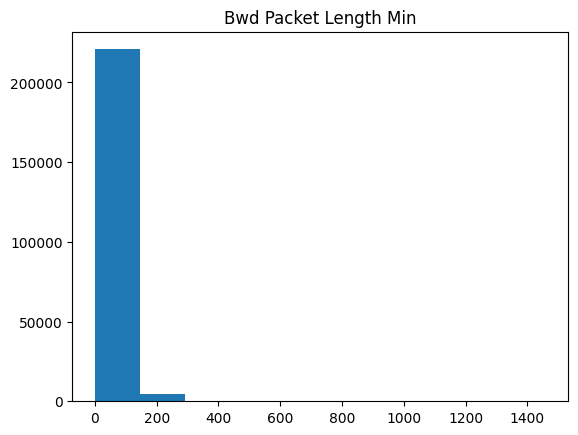

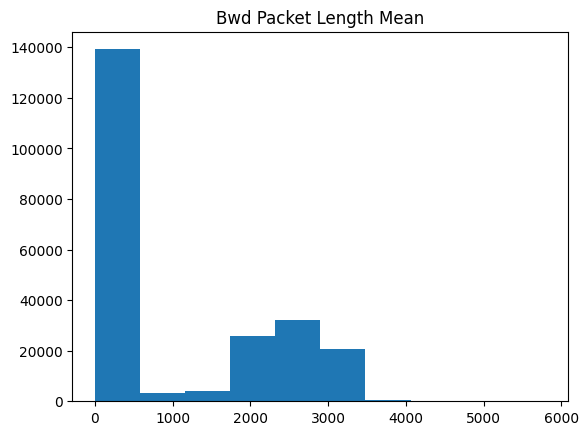

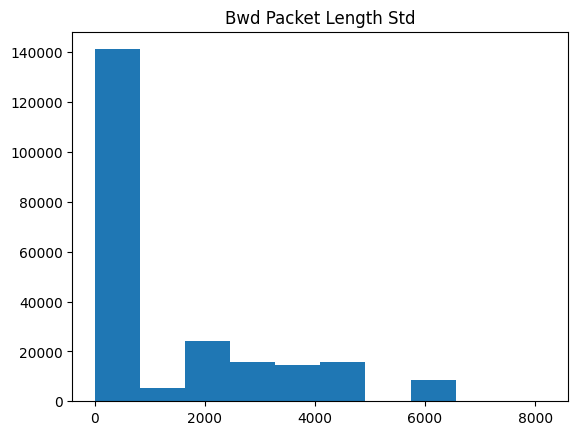

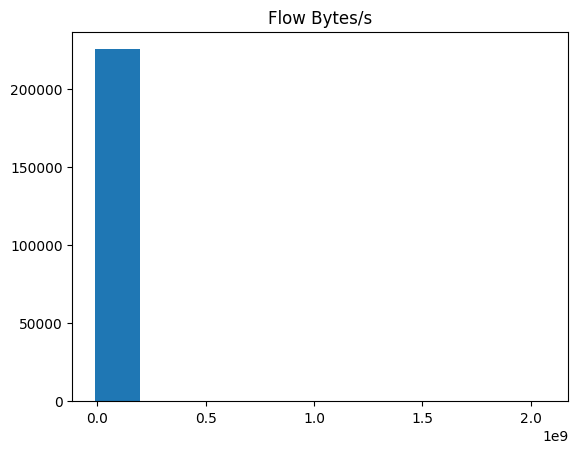

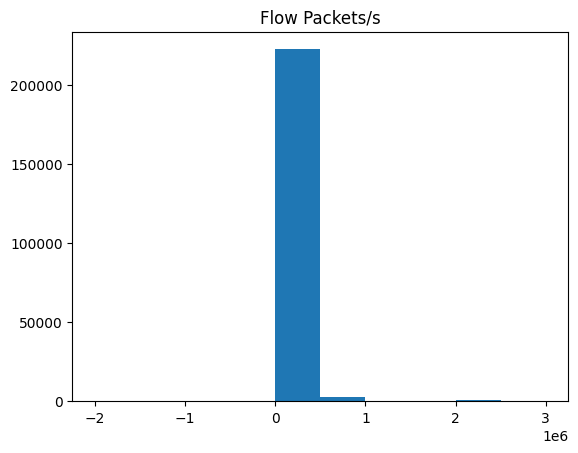

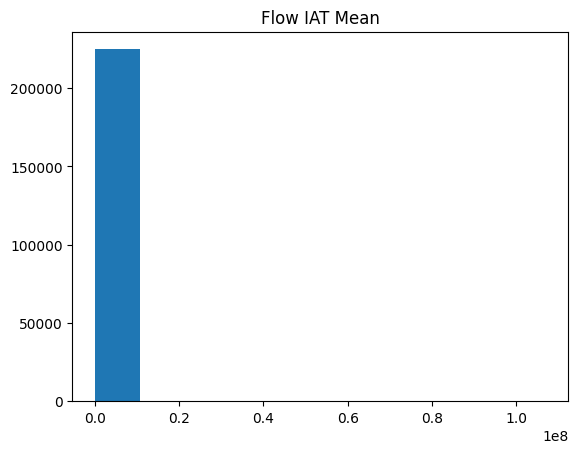

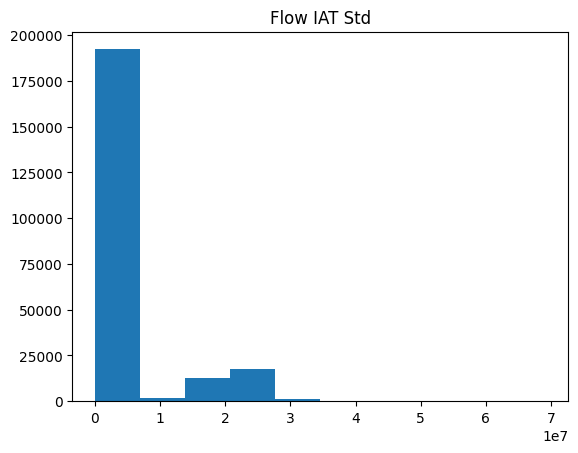

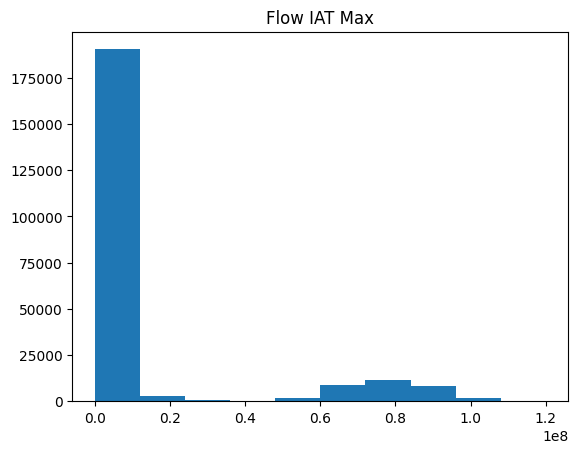

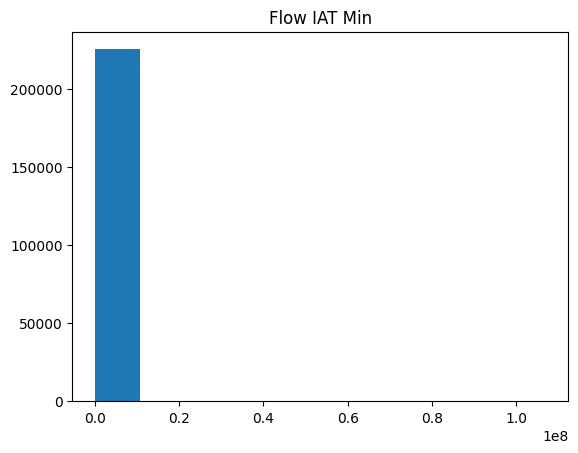

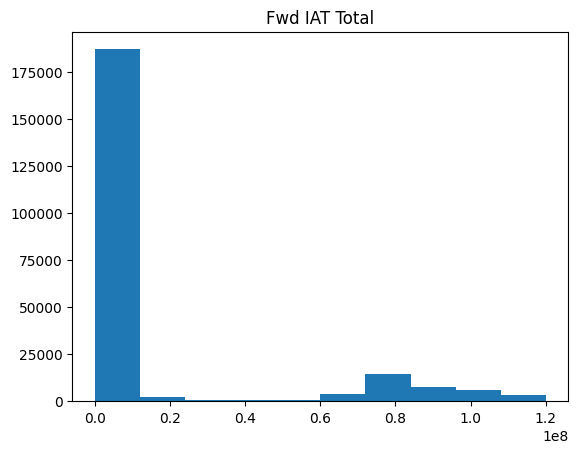

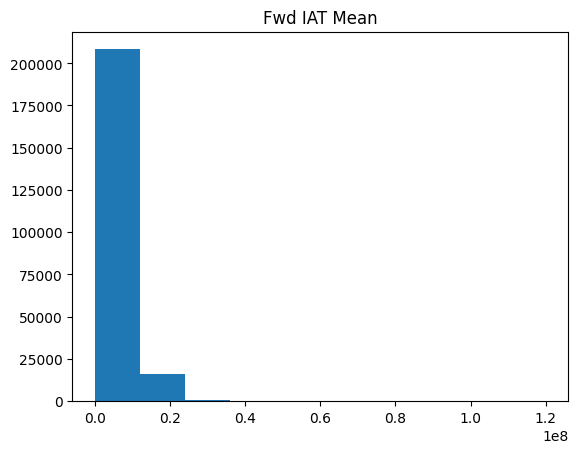

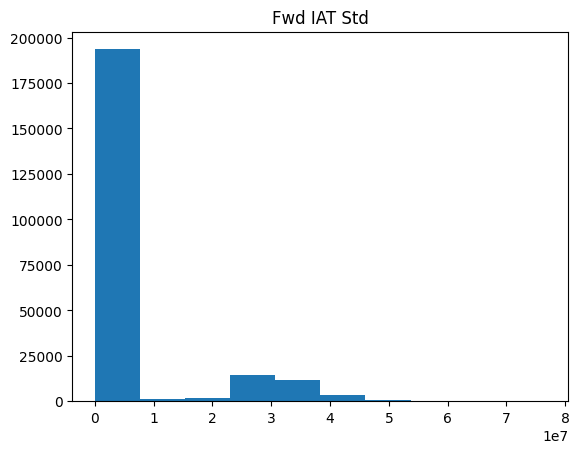

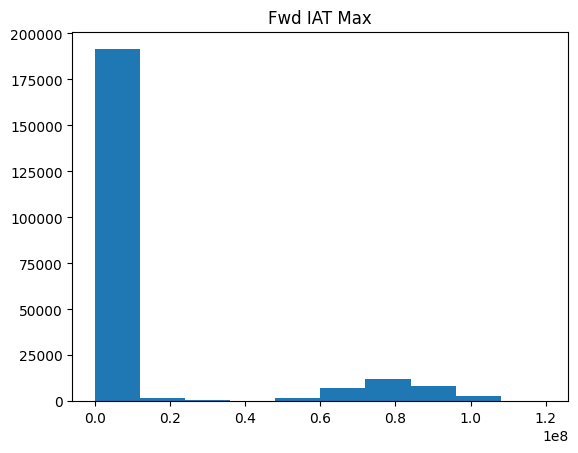

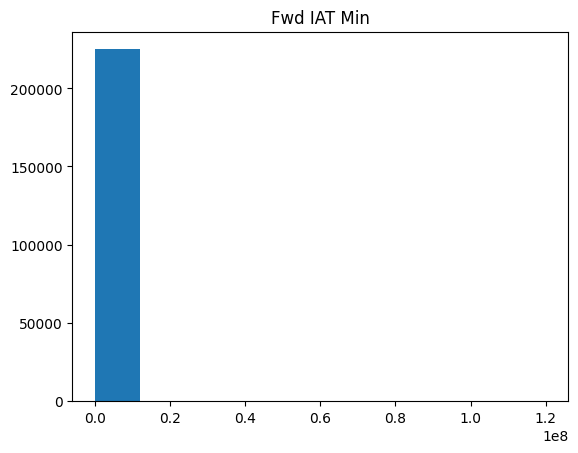

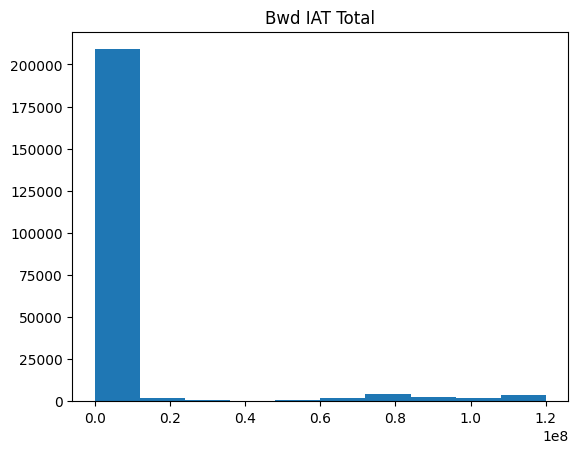

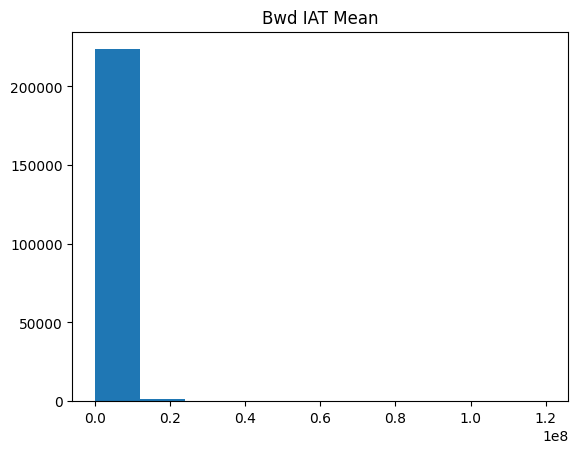

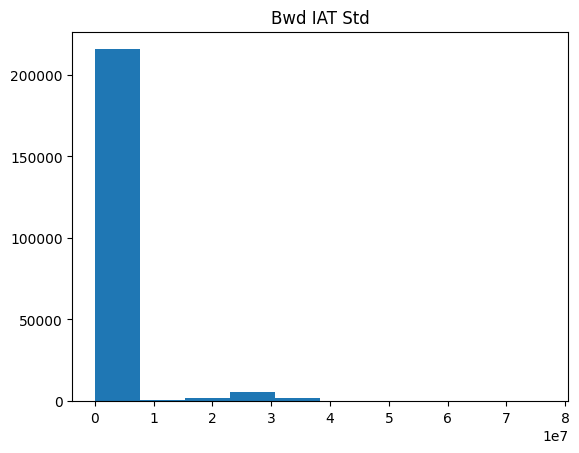

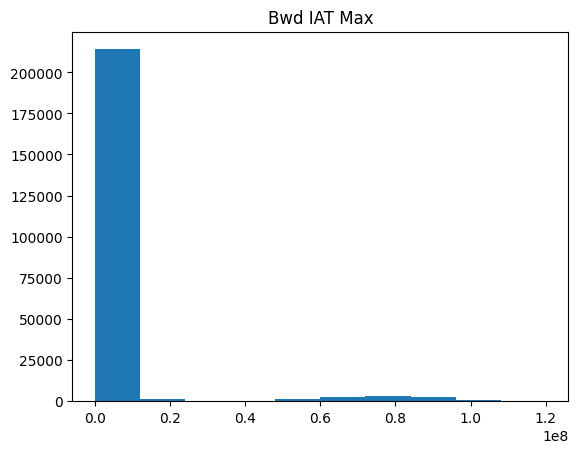

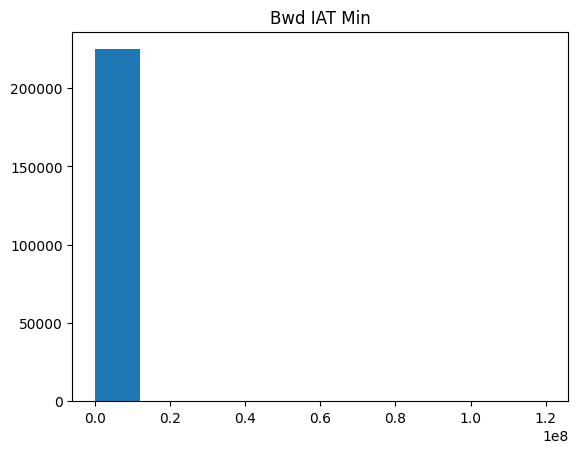

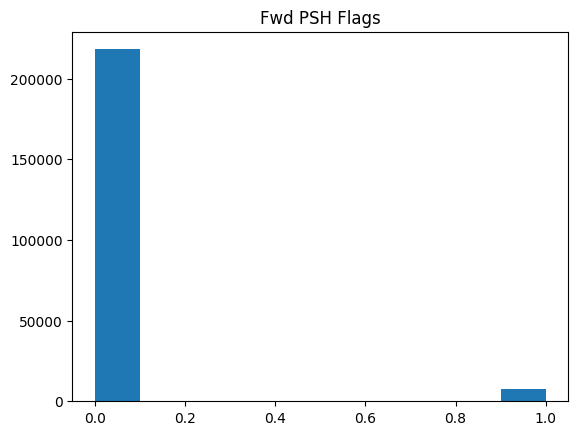

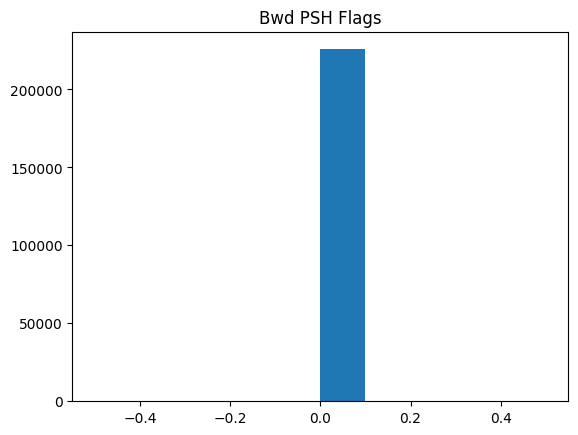

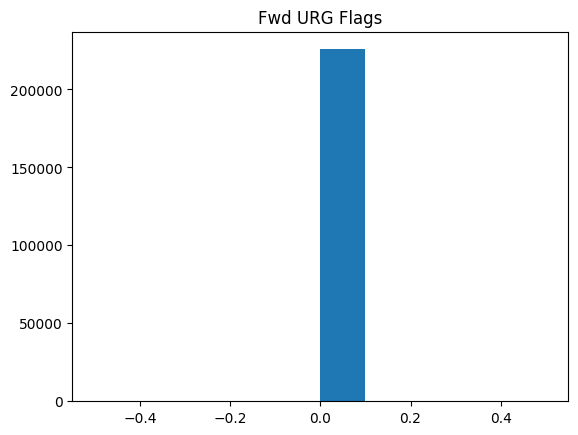

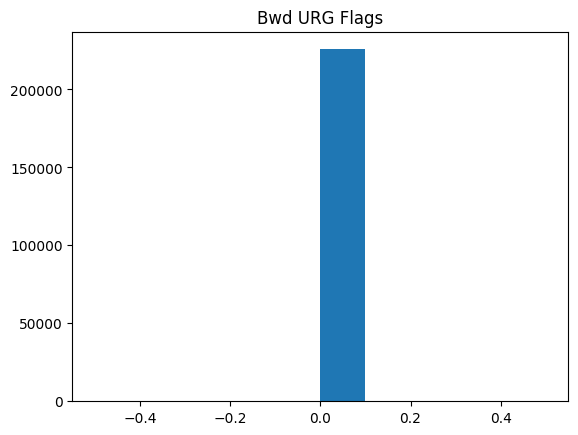

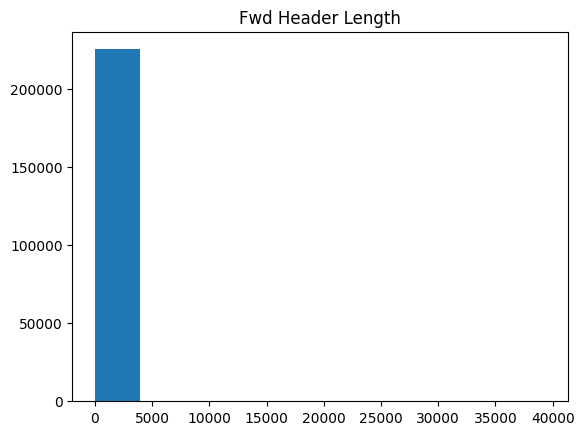

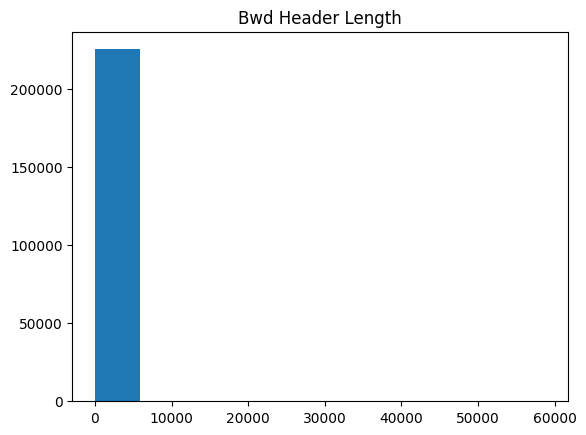

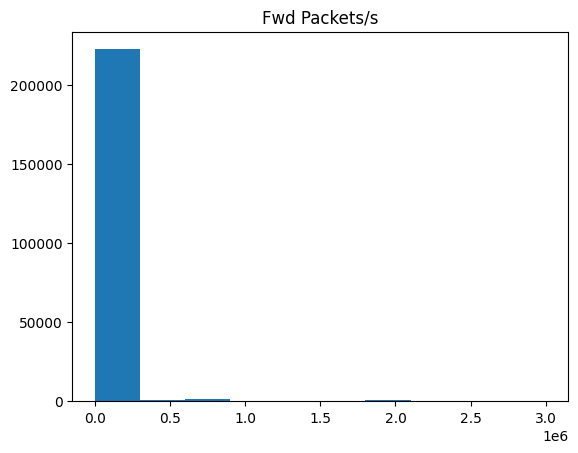

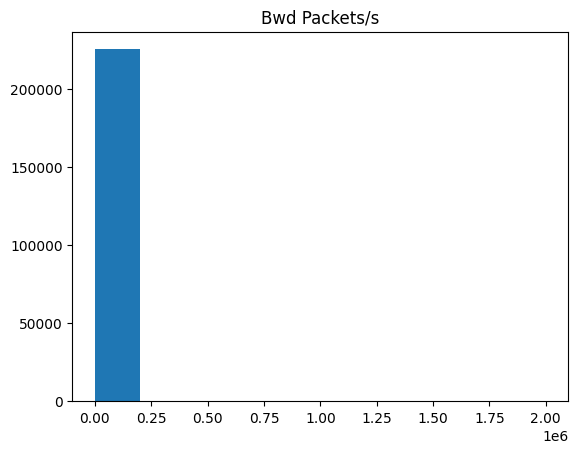

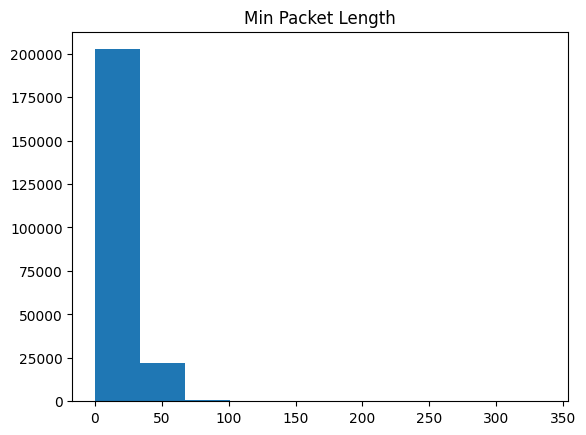

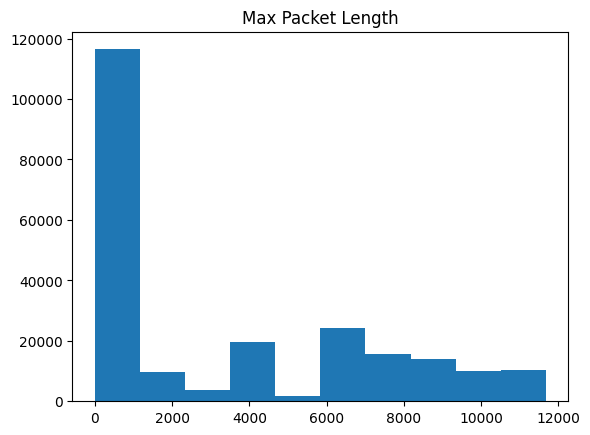

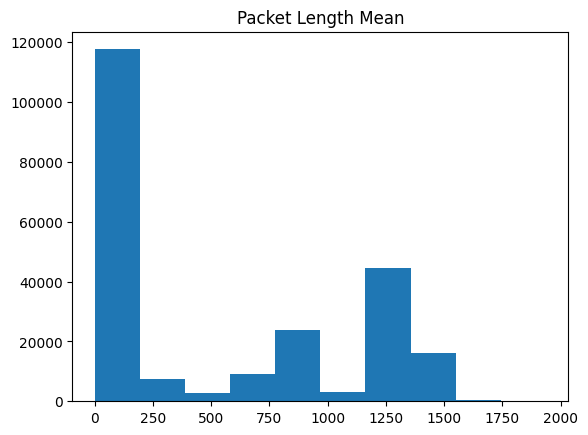

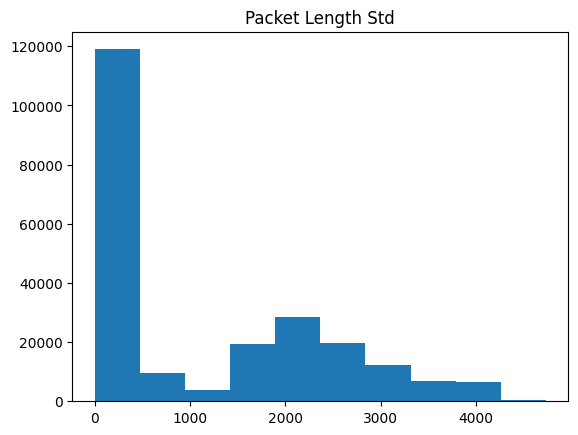

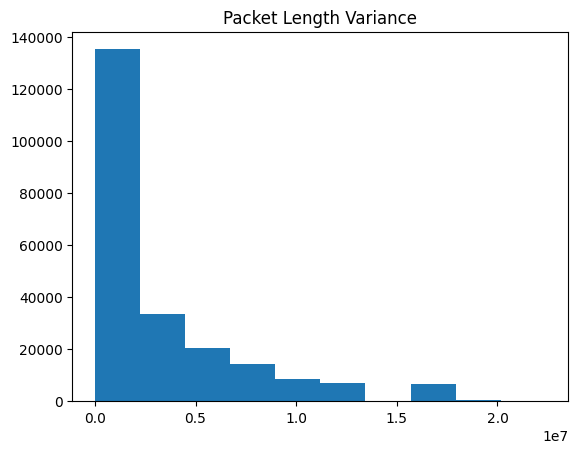

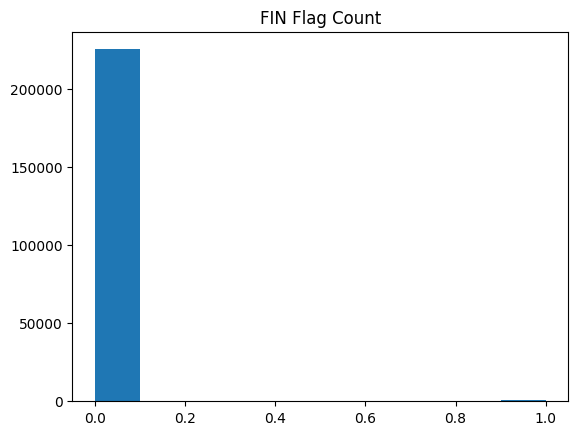

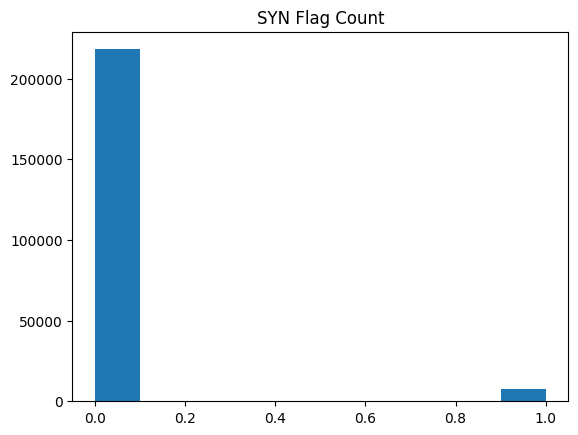

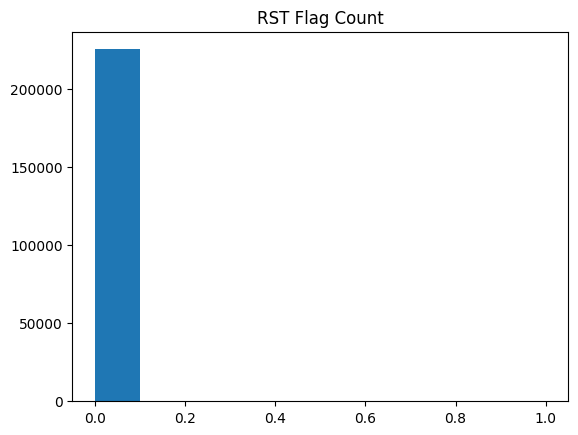

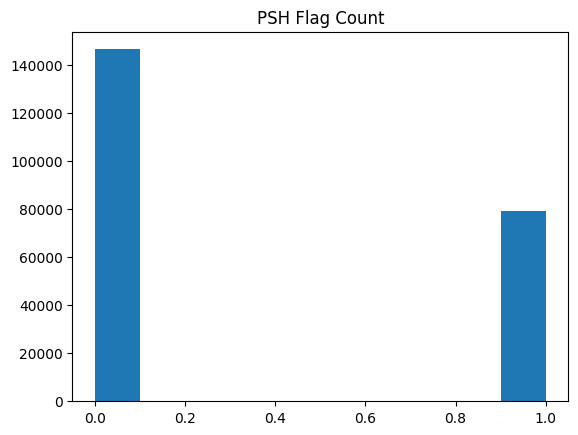

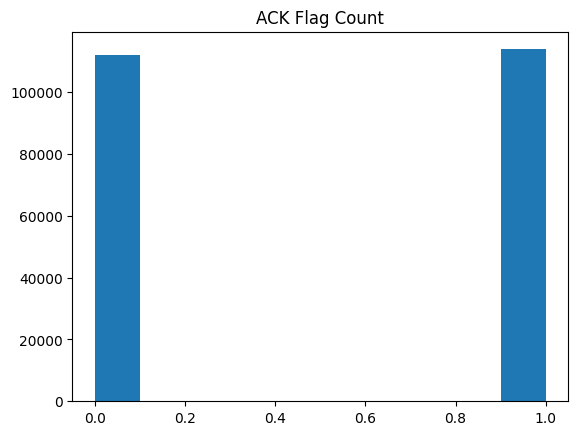

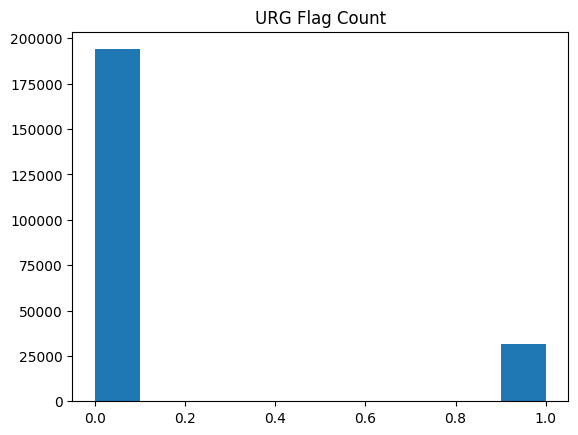

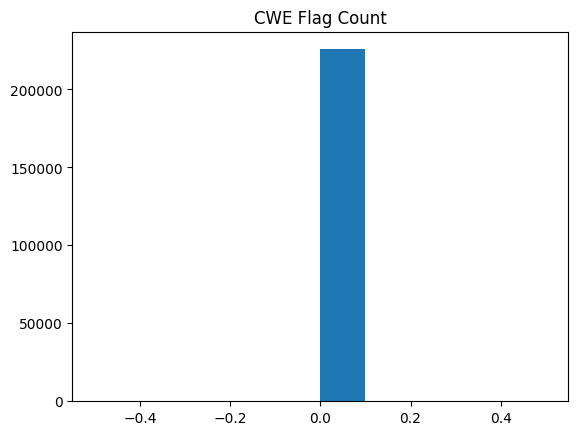

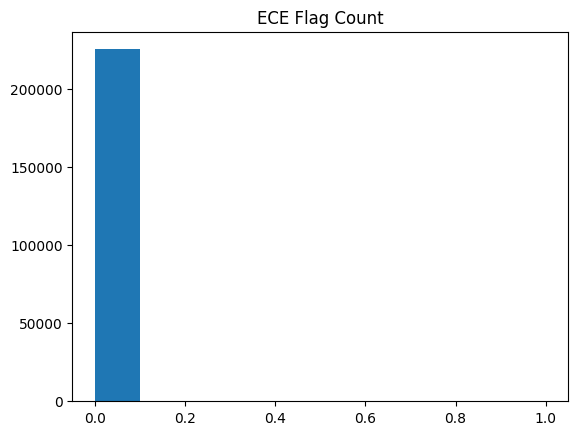

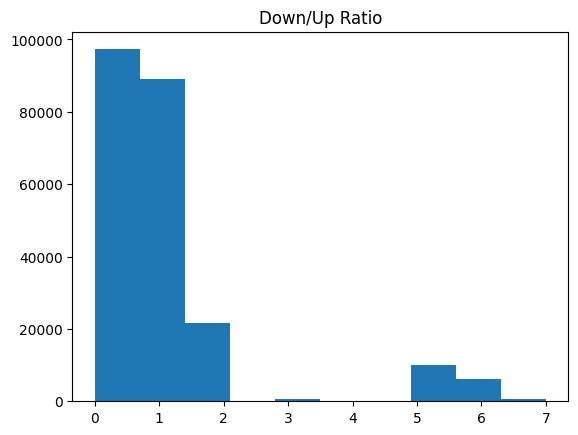

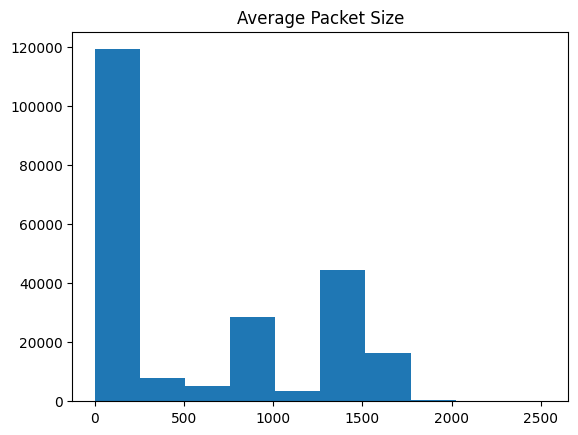

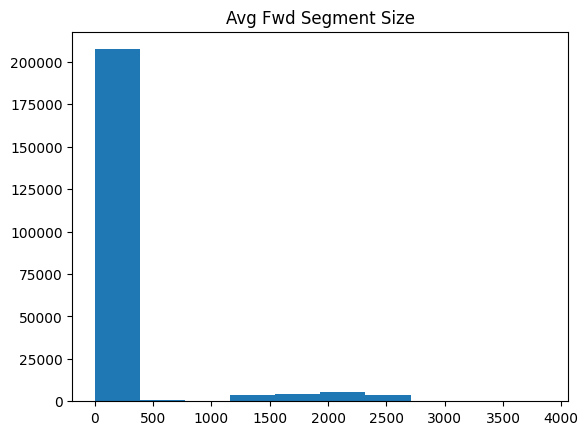

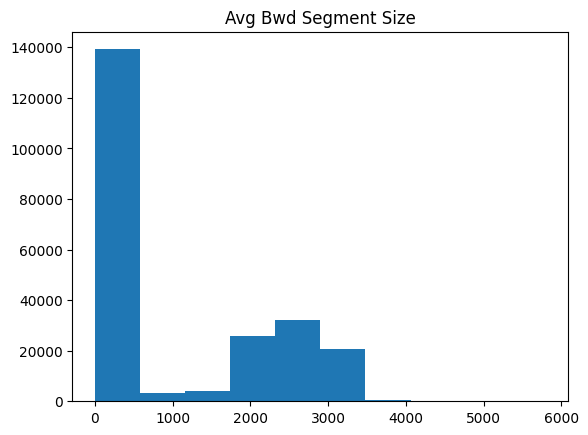

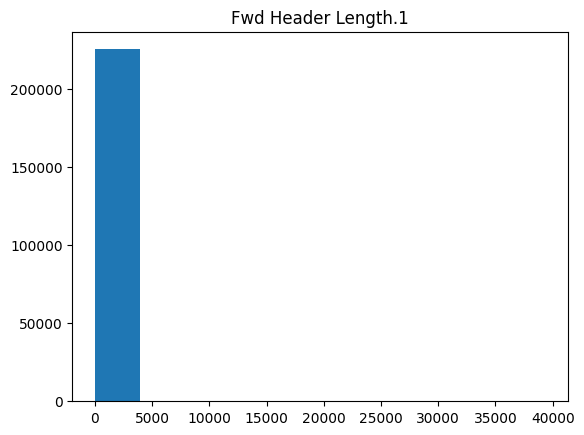

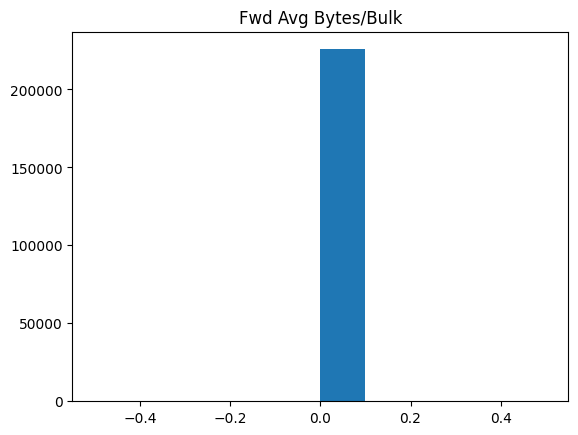

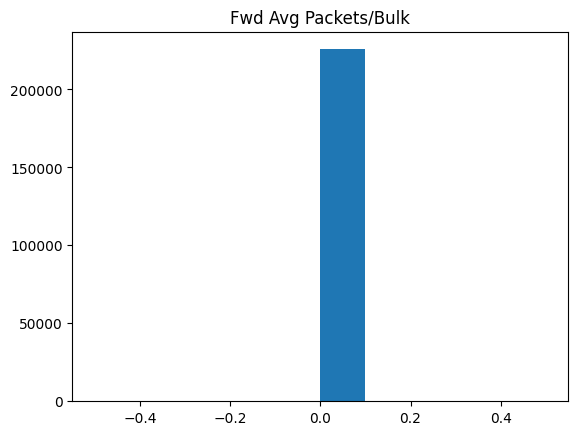

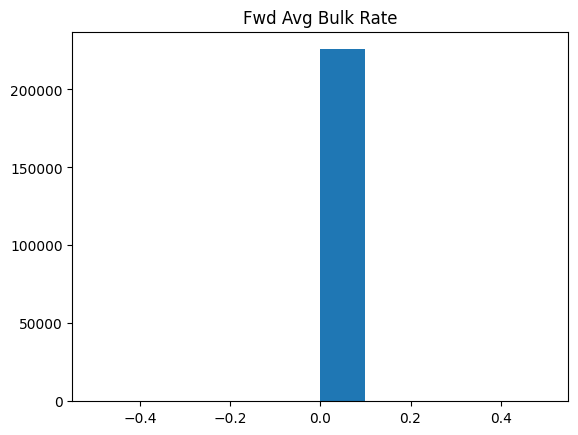

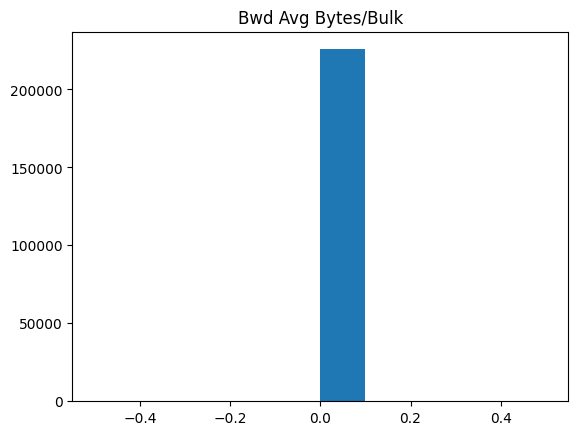

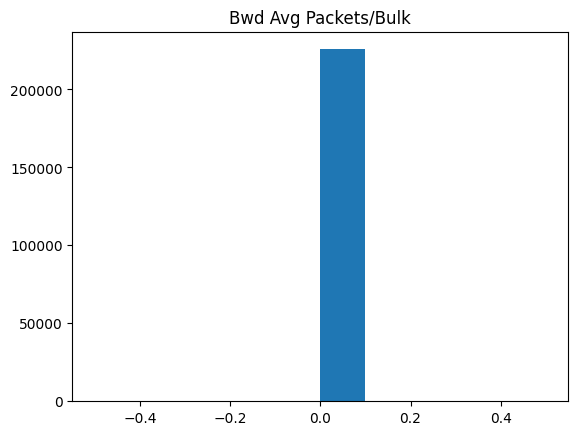

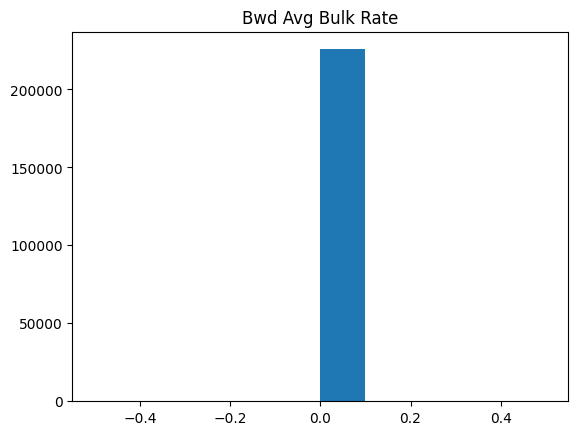

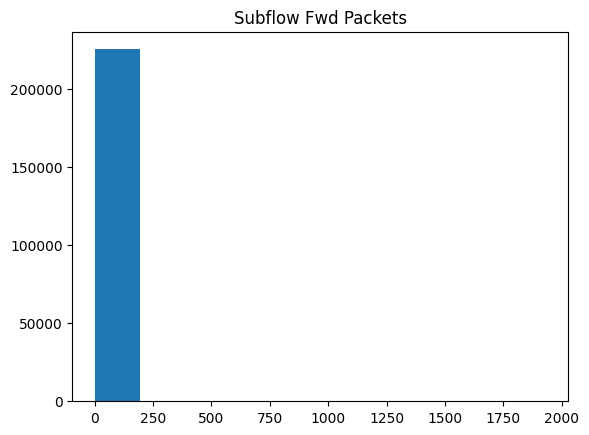

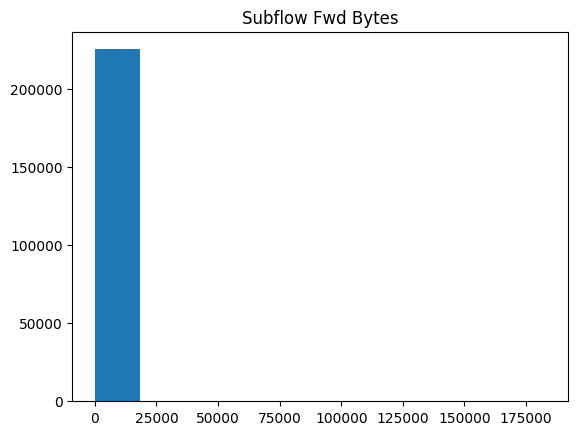

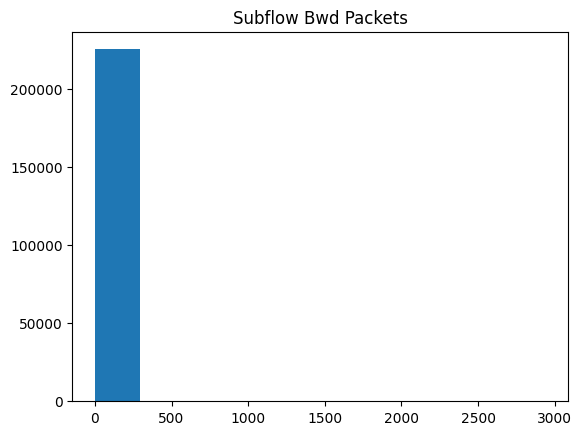

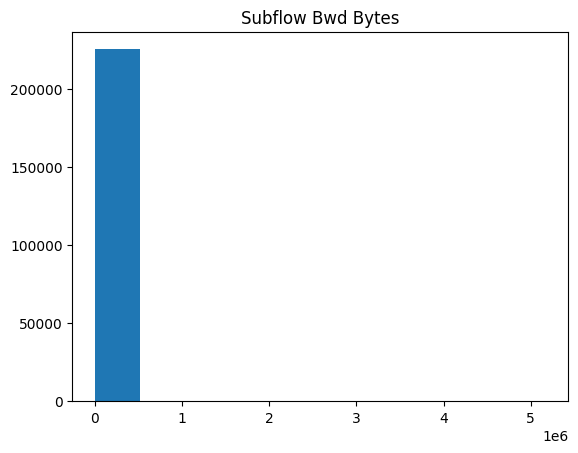

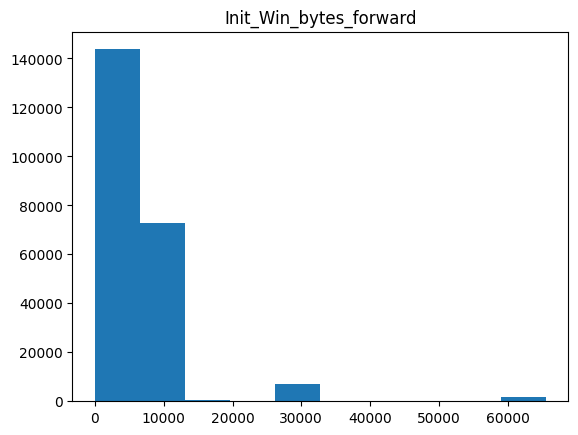

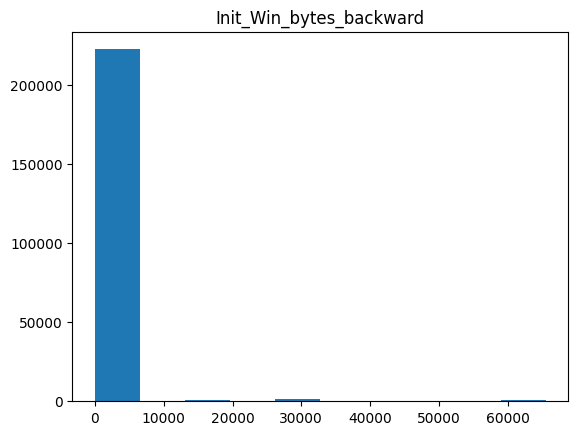

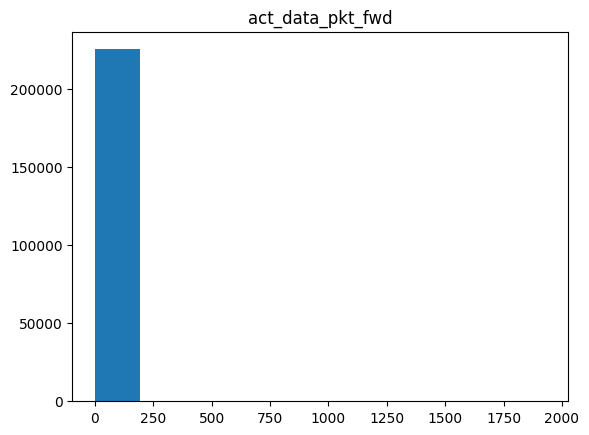

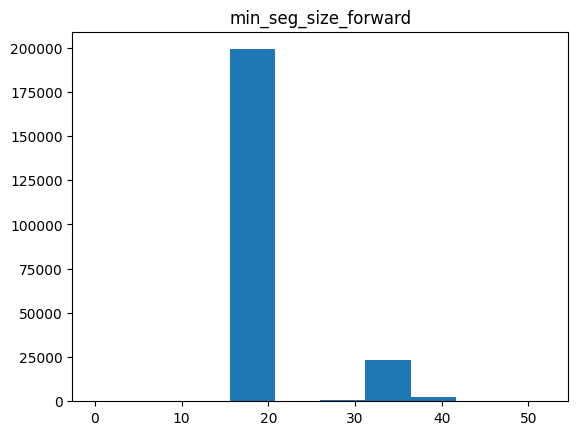

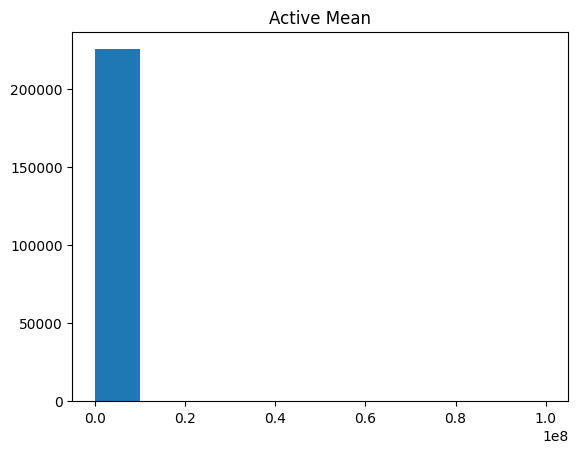

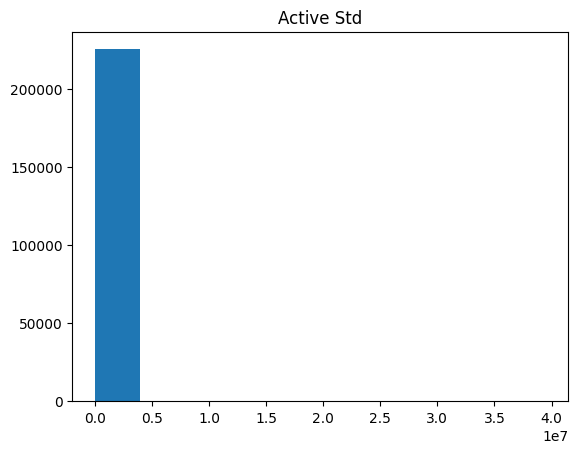

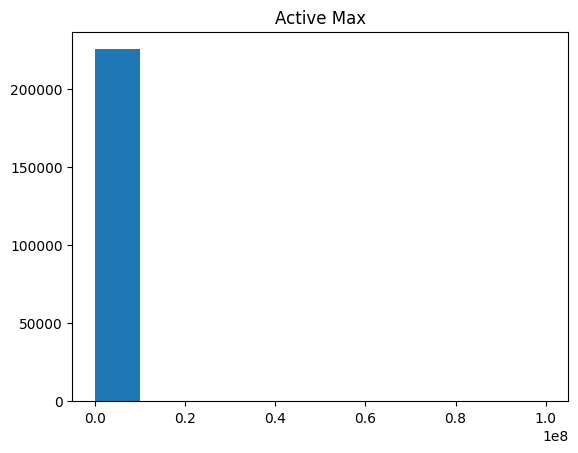

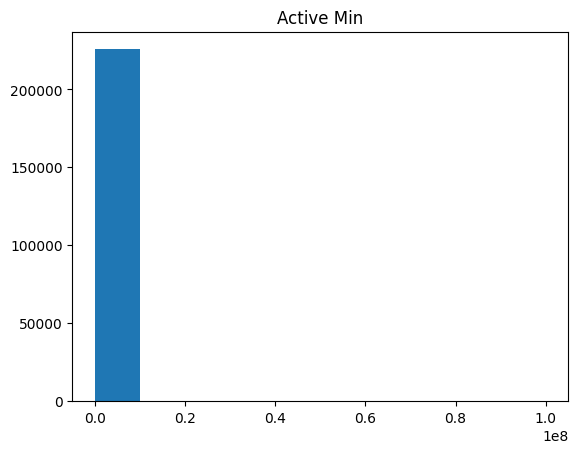

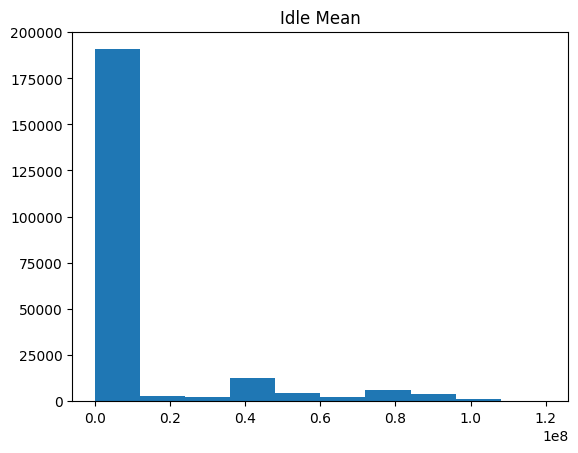

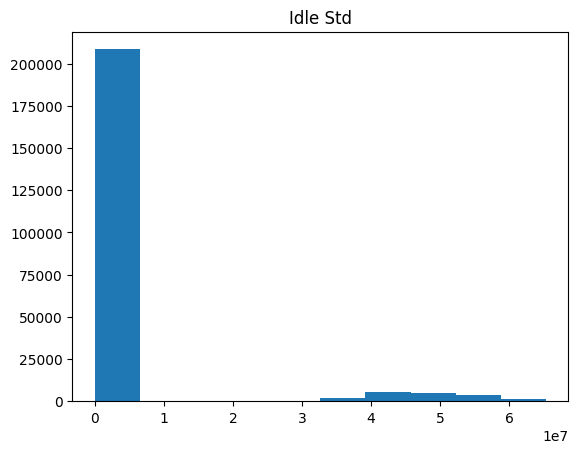

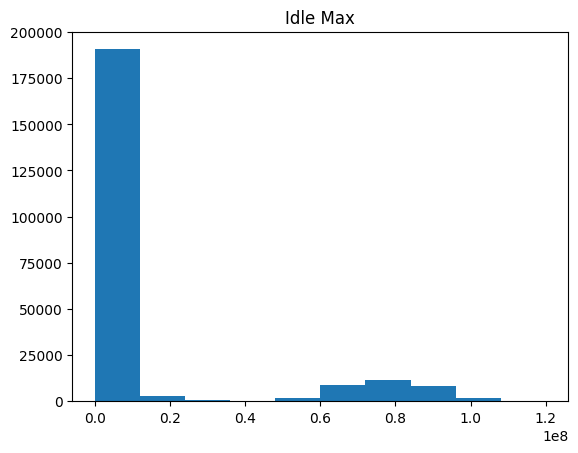

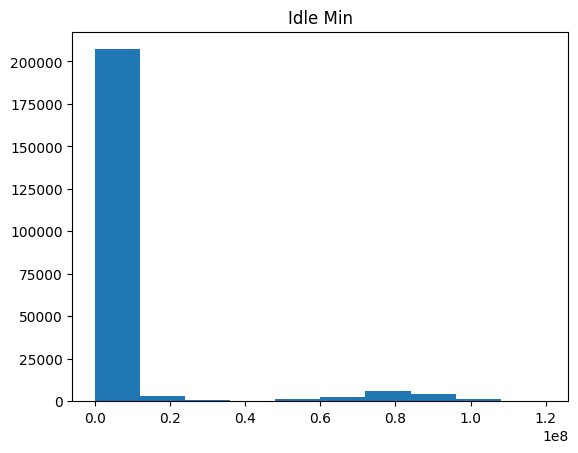

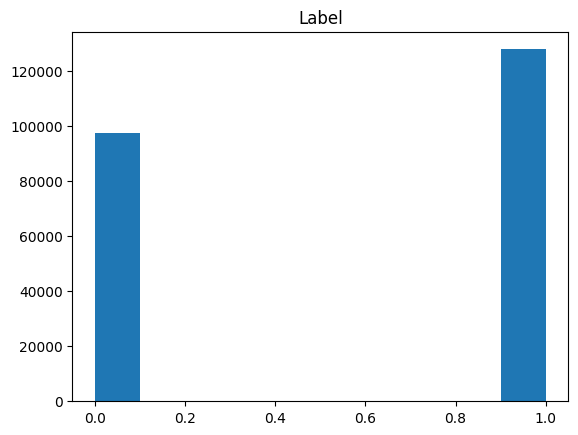

In [115]:
# Create a histogram plot for each feature
plt.figure(5)
for col in df2.columns:
    plt.hist(df2[col])
    plt.title(col)
    plt.show()

In [120]:
X = df2.drop('Label',axis = 1)
y = df2['Label']

In [122]:
from sklearn.model_selection import train_test_split

In [123]:
X_train,X_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)

In [124]:
X_train

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
150483,80,96603635,8,5,56,11607,20,0,7.000000,5.656854,...,6,20,666002.0,0.0,666002,666002,95700000.0,0.0,95700000,95700000
27917,80,3524574,5,0,30,0,6,6,6.000000,0.000000,...,4,20,0.0,0.0,0,0,0.0,0.0,0,0
44675,80,6108847,5,0,30,0,6,6,6.000000,0.000000,...,4,20,1018.0,0.0,1018,1018,6107829.0,0.0,6107829,6107829
5374,55303,2325,2,0,12,0,6,6,6.000000,0.000000,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
12721,53,195383,2,2,100,316,50,50,50.000000,0.000000,...,1,32,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119895,22,232,1,1,6,6,6,6,6.000000,0.000000,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
103710,26770,10027391,1,5,6,30,6,6,6.000000,0.000000,...,0,20,34645.0,0.0,34645,34645,9992746.0,0.0,9992746,9992746
131949,80,76735,3,6,26,11601,20,0,8.666667,10.263203,...,2,20,0.0,0.0,0,0,0.0,0.0,0,0
146884,57980,93626759,6,10,11607,68,7300,0,1934.500000,2863.744245,...,4,20,23130.0,0.0,23130,23130,46800000.0,53900000.0,84900000,8690725


In [125]:
y_train

,Label
150483,1
27917,1
44675,1
5374,0
12721,0
...,...
119895,0
103710,0
131949,1
146884,0


In [126]:
print("The train dataset size = ",X_train.shape)
print("The test dataset size = ",X_test.shape)

The train dataset size =  (157997, 78)
The test dataset size =  (67714, 78)
